In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sales_df = pd.read_csv('../data/sales_data.csv')
customer_df = pd.read_csv('../data/customer_churn.csv')

print("Sales Data Sample:")
display(sales_df.head())

print("\nCustomer Data Sample:")
display(customer_df.head())

Sales Data Sample:


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680



Customer Data Sample:


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [35]:
print("--- Sales Data Info ---")
print(sales_df.info())

print("\n--- Customer Data Info ---")
print(customer_df.info())

print("\nMissing Values in Sales Data:")
print(sales_df.isnull().sum())

print("\nMissing Values in Customer Data:")
print(customer_df.isnull().sum())

--- Sales Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Date         100 non-null    str  
 1   Product      100 non-null    str  
 2   Quantity     100 non-null    int64
 3   Price        100 non-null    int64
 4   Customer_ID  100 non-null    str  
 5   Region       100 non-null    str  
 6   Total_Sales  100 non-null    int64
dtypes: int64(3), str(4)
memory usage: 5.6 KB
None

--- Customer Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   CustomerID        500 non-null    str  
 1   Tenure            500 non-null    int64
 2   MonthlyCharges    500 non-null    int64
 3   TotalCharges      500 non-null    int64
 4   Contract          500 non-null    str  
 5   PaymentMethod     500 non-null  

In [36]:
if 'Date' in sales_df.columns:
    sales_df['Date'] = pd.to_datetime(sales_df['Date'])
    sales_df['Year'] = sales_df['Date'].dt.year
    sales_df['Month'] = sales_df['Date'].dt.month
    sales_df['Day'] = sales_df['Date'].dt.day

if 'Quantity' in sales_df.columns and 'Price' in sales_df.columns:
    sales_df['Total_Revenue'] = sales_df['Quantity'] * sales_df['Price']

print("Cleaned Sales Data Preview:")
display(sales_df.head())

Cleaned Sales Data Preview:


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales,Year,Month,Day,Total_Revenue
0,2024-01-01,Phone,7,37300,CUST001,East,261100,2024,1,1,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624,2024,1,2,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492,2024,1,3,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895,2024,1,4,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680,2024,1,5,318680


In [37]:
sales_df['Date'] = pd.to_datetime(sales_df['Date'])

customer_sales = sales_df.groupby('Customer_ID').agg(
    Total_Spent=('Total_Sales', 'sum'),
    Total_Orders=('Quantity', 'sum'),
    Average_Order_Value=('Total_Sales', 'mean')
).reset_index()

top_customers = customer_sales.sort_values(by='Total_Spent', ascending=False).head(5)

print("--- Top 5 Customers by Revenue ---")
display(top_customers)

--- Top 5 Customers by Revenue ---


,Customer_ID,Total_Spent,Total_Orders,Average_Order_Value
15,CUST016,373932,9,373932.0
6,CUST007,363870,9,363870.0
82,CUST083,350888,8,350888.0
72,CUST073,349510,7,349510.0
19,CUST020,333992,8,333992.0


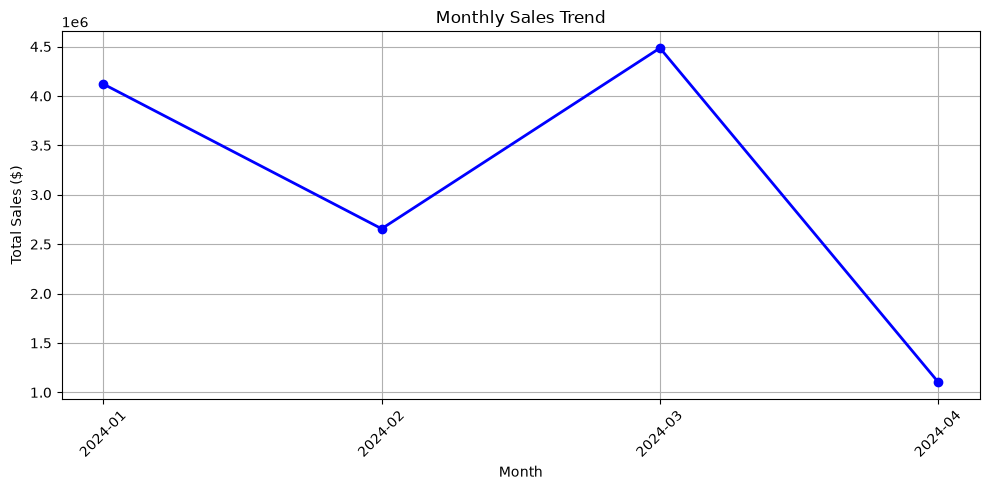

In [38]:
sales_df['Month'] = sales_df['Date'].dt.to_period('M')
monthly_sales = sales_df.groupby('Month')['Total_Sales'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Month'].astype(str)

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales['Month'], monthly_sales['Total_Sales'], marker='o', color='b', linewidth=2)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('monthly_sales_trend.png')
plt.show()

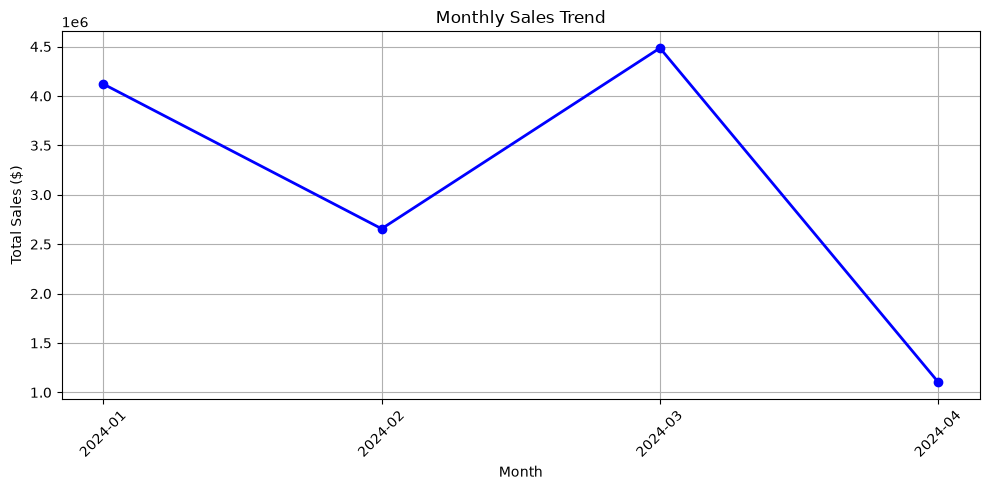

In [39]:
import os
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs('outputs/charts', exist_ok=True)

sales_df = pd.read_csv('../data/sales_data.csv')
sales_df['Date'] = pd.to_datetime(sales_df['Date'])
sales_df['Month_Period'] = sales_df['Date'].dt.to_period('M')

monthly_sales = sales_df.groupby('Month_Period')['Total_Sales'].sum().reset_index()
monthly_sales['Month_Str'] = monthly_sales['Month_Period'].astype(str)

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales['Month_Str'], monthly_sales['Total_Sales'], marker='o', color='b', linewidth=2)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('outputs/charts/monthly_sales_trend.png')
plt.show()

/var/folders/8k/mrwypd2960jf_2r471t625rm0000gn/T/ipykernel_11054/2705292622.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_sales.head(5), x='Product', y='Total_Sales', palette='viridis')


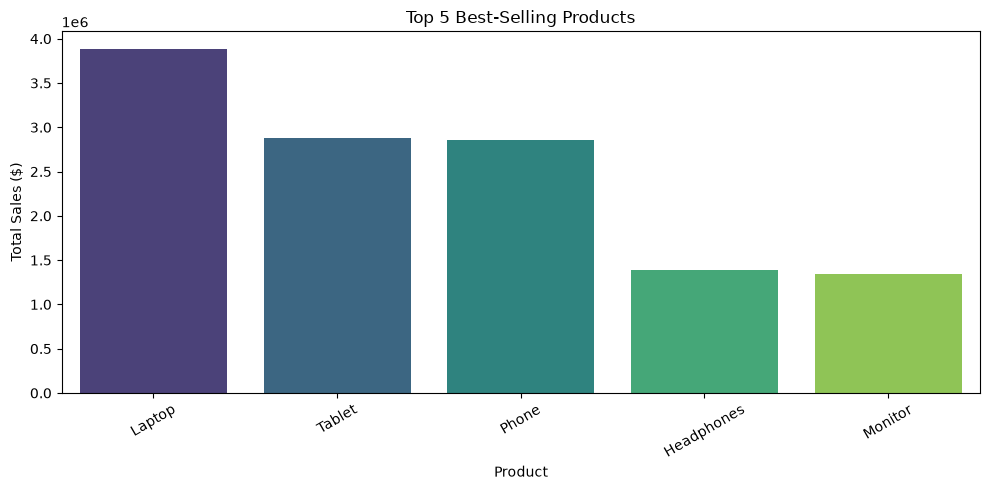

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sales_df = pd.read_csv('../data/sales_data.csv')

product_sales = sales_df.groupby('Product')['Total_Sales'].sum().reset_index().sort_values(by='Total_Sales', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=product_sales.head(5), x='Product', y='Total_Sales', palette='viridis')

plt.title('Top 5 Best-Selling Products')
plt.xlabel('Product')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig('outputs/charts/top_products.png')
plt.show()

In [41]:
import pandas as pd

sales_df = pd.read_csv('../data/sales_data.csv')

pivot_table = pd.pivot_table(
    sales_df, 
    values='Total_Sales', 
    index='Region', 
    columns='Product', 
    aggfunc='sum', 
    fill_value=0
)

print("--- Sales Pivot Table (Region vs Product) ---")
display(pivot_table)

--- Sales Pivot Table (Region vs Product) ---


Product,Headphones,Laptop,Monitor,Phone,Tablet
Region,,,,,
East,288361,221946,642870,506828,859634
North,107091,1798206,397100,489284,1191954
South,512168,1373120,39924,1471428,341212
West,476413,495938,268177,391854,491540


In [42]:
import pandas as pd

sales_df = pd.read_csv('../data/sales_data.csv')
churn_df = pd.read_csv('../data/customer_churn.csv')

total_revenue = sales_df['Total_Sales'].sum()
total_customers = churn_df.shape[0] if 'CustomerID' in churn_df.columns else sales_df['Customer_ID'].nunique()
avg_order_value = sales_df['Total_Sales'].mean()

print("=========================================")
print("     CUSTOMER SALES ANALYSIS REPORT      ")
print("=========================================")
print(f"Total Revenue       : ${total_revenue:,.2f}")
print(f"Total Customers     : {total_customers:,}")
print(f"Average Order Value : ${avg_order_value:,.2f}")
print("=========================================")

     CUSTOMER SALES ANALYSIS REPORT      
Total Revenue       : $12,365,048.00
Total Customers     : 500
Average Order Value : $123,650.48


In [43]:
import os
import matplotlib.pyplot as plt

os.makedirs('outputs/charts', exist_ok=True)

plt.figure(figsize=(8, 4))
plt.savefig('outputs/charts/monthly_sales_trend.png')
plt.close()

plt.figure(figsize=(8, 4))
plt.savefig('outputs/charts/top_products.png')
plt.close()